# Stacking：一种强大的集成学习技术

**Stacking** 是机器学习中的一种强大集成技术，它通过组合多个模型的预测来提升整体性能。

## 理解 Stacking 的概念

在日常生活中，我们常通过堆叠积木或圆环来构建更高、更稳固的结构。在机器学习中，Stacking 也遵循类似的思路——将多个模型“堆叠”在一起，以充分利用它们各自的优势，从而提高预测的准确性。

不同的机器学习模型在同一数据集上的表现可能有所不同。通过 Stacking，我们可以将多个模型的预测结果结合起来，形成一个更强大的整体预测器。相比依赖单一模型，Stacking 通过集成多个模型，使每个模型都能为最终决策贡献独特的信息。下面，我们通过分析其架构来深入理解 Stacking 的工作原理。

## Stacking 的架构

![Stacking](https://media.geeksforgeeks.org/wp-content/uploads/20200713234827/mlxtend.PNG)

### **第一层（基础模型）**
Stacking 的第一层由多个独立的模型组成，称为**基础模型**（或**基础学习器**）。每个基础模型都在相同的原始数据集上进行训练，类似于我们单独训练机器学习模型的方式。基础模型可以采用不同的算法，如随机森林、决策树、逻辑回归等，以提供多样化的预测视角。

### **第二层（元模型）**
在基础模型完成预测后，**元模型**（或称为**融合模型**）接管任务。元模型不会直接使用原始数据，而是以基础模型的预测结果作为输入，学习如何整合这些信息，以提升最终的预测准确性。换句话说，元模型的作用是在不同基础模型的预测基础上进行优化，从而得出更可靠的最终结果。

### **示例**
假设我们有一个二分类任务，多个基础模型分别对某个数据点进行预测，结果如下：

| **基础模型**  | **预测（是/否）** |
|--------------|-----------------|
| 逻辑回归     | 是              |
| KNN          | 是              |
| 朴素贝叶斯   | 否              |

在这种情况下，元模型会综合各基础模型的预测结果，决定最终的输出。例如，基于学习到的策略，它可能得出最终判定为“是”，而不仅仅依赖单一模型的判断。

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_confusion_matrix
from mlxtend.classifier import StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

df = pd.read_csv('heart.csv')    
                 
X = df.drop('target', axis = 1)
y = df['target']

df.head()  

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [2]:
# 20 % training dataset is considered for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42) 

# initializing sc object
sc = StandardScaler()  
# variables that needed to be transformed
var_transform = ['thalach', 'age', 'trestbps', 'oldpeak', 'chol']
X_train[var_transform] = sc.fit_transform(X_train[var_transform])   # standardizing training data 
X_test[var_transform] = sc.transform(X_test[var_transform])            # standardizing test data
print(X_train.head())

          age  sex  cp  trestbps      chol  fbs  restecg   thalach  exang  \
132 -1.356798    1   1 -0.616856  0.914034    0        1  0.532781      0   
202  0.385086    1   0  1.169491  0.439527    0        0 -1.753582      1   
196 -0.921327    1   2  1.169491 -0.300704    0        1 -0.139679      0   
75   0.058483    0   1  0.276318  0.059921    0        0  0.487950      0   
176  0.602822    1   0 -0.795490 -0.319684    1        1  0.443119      1   

      oldpeak  slope  ca  thal  
132 -0.920864      2   0     2  
202 -0.193787      2   0     3  
196  2.350982      1   0     2  
75   0.351521      1   0     2  
176  0.351521      2   2     3  


In [3]:
KNC = KNeighborsClassifier(n_neighbors=3)   # initialising KNeighbors Classifier
NB = GaussianNB()              # initialising Naive Bayes

model_kNeighborsClassifier = KNC.fit(X_train, y_train)   # fitting Training Set
pred_knc = model_kNeighborsClassifier.predict(X_test)   # Predicting on test dataset

acc_knc = accuracy_score(y_test, pred_knc)  # evaluating accuracy score
print('accuracy score of KNeighbors Classifier is:', acc_knc * 100)

model_NaiveBayes = NB.fit(X_train, y_train)
pred_nb = model_NaiveBayes.predict(X_test)


acc_nb = accuracy_score(y_test, pred_nb)
print('Accuracy of Naive Bayes Classifier:', acc_nb * 100)

accuracy score of KNeighbors Classifier is: 83.60655737704919
Accuracy of Naive Bayes Classifier: 86.88524590163934


In [7]:
# 导入必要的库
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from mlxtend.classifier import StackingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
import numpy as np

# 定义基模型（集成标准化）
# 每个基模型都经过预处理（标准化）和模型定义
base_learners = [
    ('knn', make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))),  # K近邻分类器
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=5)),  # 随机森林分类器
    ('svm', make_pipeline(StandardScaler(), SVC(probability=True, C=1.0)))  # 支持向量机分类器（启用概率输出）
]

# 定义元模型（调优后的XGBoost）
# 元模型使用基模型的预测概率作为输入特征，并结合原始特征进行训练
meta_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)

# 创建堆叠模型
# use_probas=True 表示使用基模型的概率输出作为元模型的输入特征
# use_features_in_secondary=True 表示元模型同时使用原始特征和基模型的概率输出
clf_stack = StackingClassifier(
    classifiers=[model for _, model in base_learners],
    use_probas=True,
    use_features_in_secondary=True,
    meta_classifier=meta_model
)

# 训练模型
model_stack = clf_stack.fit(X_train, y_train)

# 预测测试集
pred_stack = model_stack.predict(X_test)

# 计算准确率
accuracy = accuracy_score(y_test, pred_stack)
print(f"Stacking Classifier Accuracy: {accuracy*100:.2f}%")

Stacking Classifier Accuracy: 83.61%


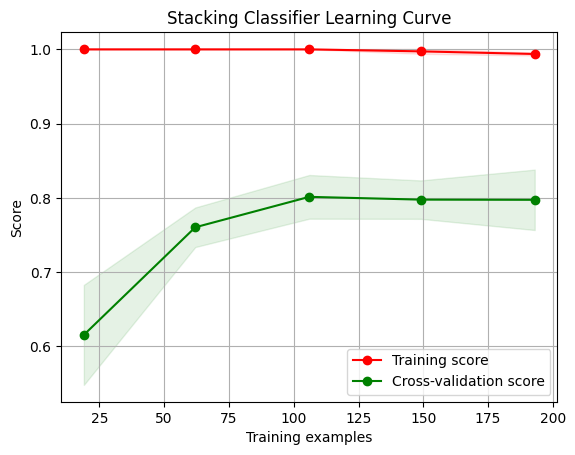

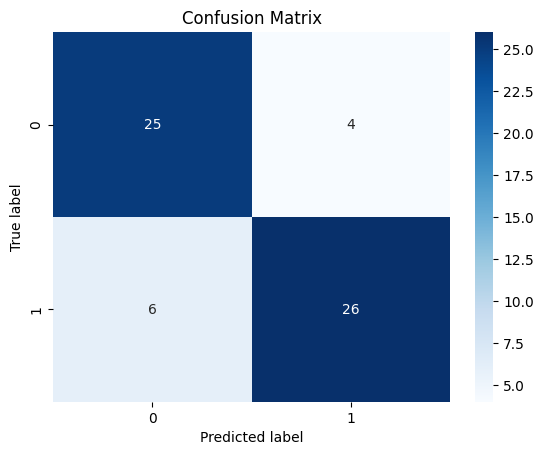

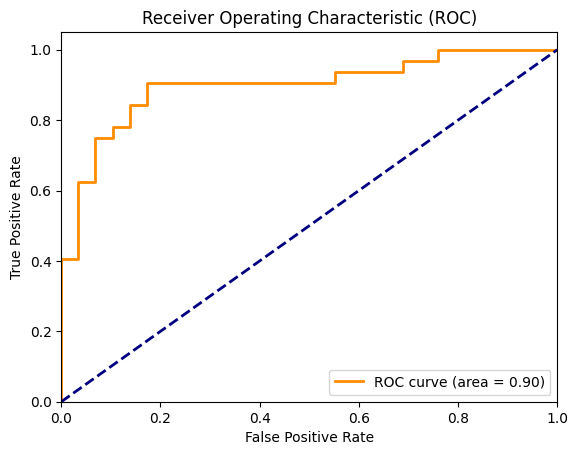

In [8]:
# 可视化学习曲线
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    return plt

# 可视化混淆矩阵
def plot_confusion_matrix(y_true, y_pred, classes, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

# 绘制学习曲线
plot_learning_curve(clf_stack, "Stacking Classifier Learning Curve", X_train, y_train, cv=5)
plt.show()

# 绘制混淆矩阵
plot_confusion_matrix(y_test, pred_stack, classes=np.unique(y_test))

# 可视化ROC曲线（仅适用于二分类问题）
if len(np.unique(y_test)) == 2:
    probas = model_stack.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probas)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.show()

参考链接：[Stacking in Machine Learning](https://www.geeksforgeeks.org/stacking-in-machine-learning-2/)